In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
customers = pd.read_csv("customers_clean.csv")
# customers.head()

,CustomerID,Age,Gender,City,Occupation,AnnualSalary,CreditScore,AccountBalance,CustomerTenureYears,BranchID
0,100001,71,Female,Delhi,Salaried,2437005,642,2907344,0,B019
1,100002,69,Female,Lucknow,Government,1151182,733,3385616,29,B034
2,100003,45,Male,Lucknow,Retired,2639833,808,4403969,0,B029
3,100004,28,Male,Bengaluru,Self Employed,2435236,761,3012595,7,B037
4,100005,27,Male,Bhopal,Salaried,4652023,769,1007542,22,B020


#Basic information

In [5]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CustomerID           15000 non-null  int64 
 1   Age                  15000 non-null  int64 
 2   Gender               15000 non-null  object
 3   City                 15000 non-null  object
 4   Occupation           15000 non-null  object
 5   AnnualSalary         15000 non-null  int64 
 6   CreditScore          15000 non-null  int64 
 7   AccountBalance       15000 non-null  int64 
 8   CustomerTenureYears  15000 non-null  int64 
 9   BranchID             15000 non-null  object
dtypes: int64(6), object(4)
memory usage: 1.1+ MB


In [6]:
customers.describe()

,CustomerID,Age,AnnualSalary,CreditScore,AccountBalance,CustomerTenureYears
count,15000.000000,15000.000000,1.500000e+04,15000.000000,1.500000e+04,15000.000000
mean,107500.500000,46.102667,2.568554e+06,708.307667,3.996016e+06,14.483733
std,4330.271354,16.400042,1.414564e+06,84.113803,2.317894e+06,8.651069
min,100001.000000,18.000000,1.201540e+05,364.000000,-2.494800e+04,0.000000
25%,103750.750000,32.000000,1.325890e+06,652.000000,1.997125e+06,7.000000
50%,107500.500000,46.000000,2.566341e+06,709.000000,4.016996e+06,14.000000
75%,111250.250000,60.000000,3.814444e+06,766.000000,6.001121e+06,22.000000
max,115000.000000,74.000000,4.999840e+06,900.000000,7.999000e+06,29.000000


Average customer age is around 46 years

Average annual salary is ₹25.6 lakhs

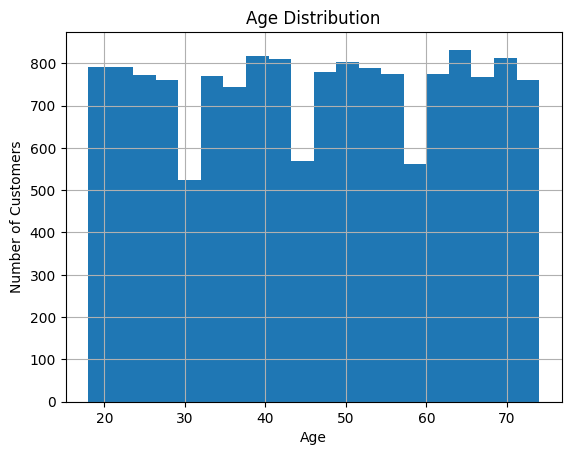

In [7]:
customers['Age'].hist(bins=20)

plt.xlabel('Age')

plt.ylabel('Number of Customers')

plt.title('Age Distribution')

plt.show()

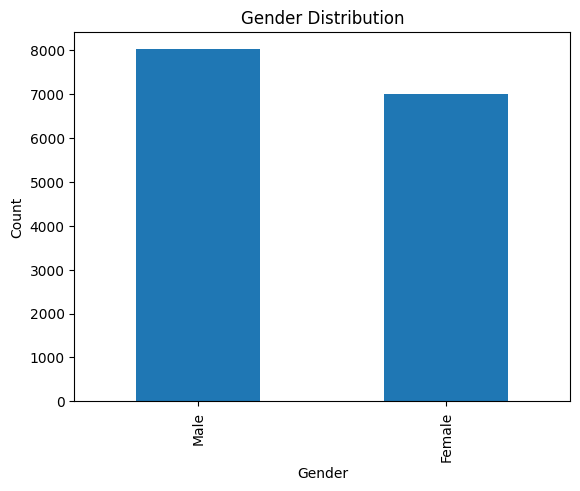

In [9]:
customers['Gender'].value_counts().plot(kind='bar')

plt.xlabel('Gender')

plt.ylabel('Count')

plt.title('Gender Distribution')

plt.show()

City-wise Customers 

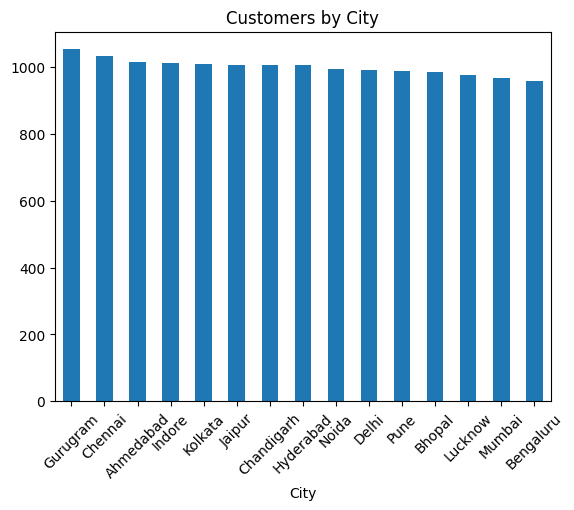

In [10]:
customers['City'].value_counts().plot(kind='bar')

plt.xticks(rotation=45)

plt.title('Customers by City')

plt.show()

#salary distribution

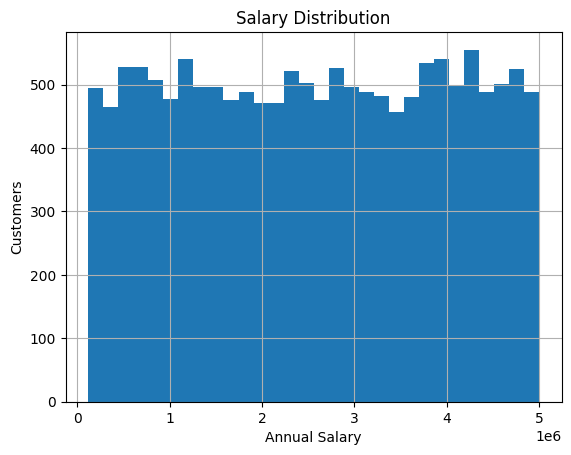

In [11]:
customers['AnnualSalary'].hist(bins=30)
plt.xlabel('Annual Salary')

plt.ylabel('Customers')

plt.title('Salary Distribution')

plt.show()

#Credit Score Distribution

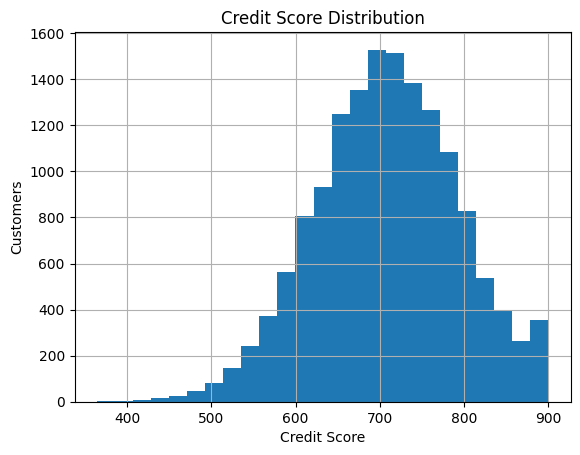

In [12]:
customers['CreditScore'].hist(bins=25)
plt.xlabel('Credit Score')

plt.ylabel('Customers')

plt.title('Credit Score Distribution')

plt.show()

#customer with low credit score

In [13]:
low_credit=customers[customers['CreditScore']<600]

In [15]:
len(low_credit)

# percenntage
(len(low_credit)/len(customers))*100


10.026666666666667

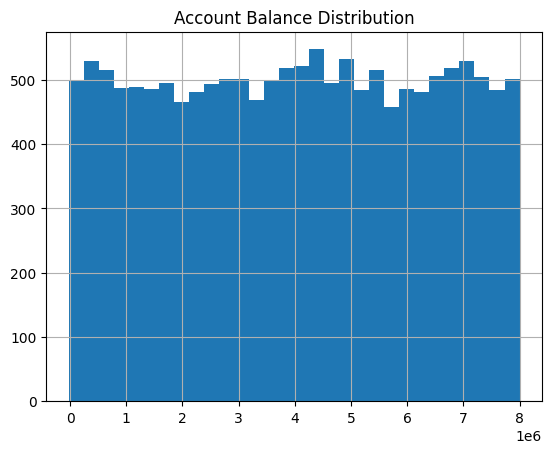

In [16]:
customers['AccountBalance'].hist(bins=30)
plt.title('Account Balance Distribution')
plt.show()

#top 10 customers by balance

In [17]:
customers.sort_values('AccountBalance',ascending=False).head(10)

,CustomerID,Age,Gender,City,Occupation,AnnualSalary,CreditScore,AccountBalance,CustomerTenureYears,BranchID
7908,107909,63,Female,Bengaluru,Retired,2513667,685,7999000,22,B045
14746,114747,53,Male,Indore,Student,2947777,612,7998349,17,B012
2219,102220,26,Female,Hyderabad,Salaried,4337952,624,7997479,27,B031
3309,103310,52,Female,Gurugram,Salaried,4651938,656,7997118,22,B001
4202,104203,55,Female,Bhopal,Self Employed,2344211,662,7997020,18,B006
3966,103967,33,Male,Jaipur,Student,3802361,693,7995845,14,B043
7637,107638,65,Female,Bengaluru,Business,2681800,704,7995828,13,B011
7214,107215,64,Male,Noida,Salaried,637541,689,7995364,26,B041
10649,110650,23,Female,Chennai,Retired,3319192,648,7994925,24,B033
4468,104469,29,Female,Indore,Government,520198,677,7994485,29,B046


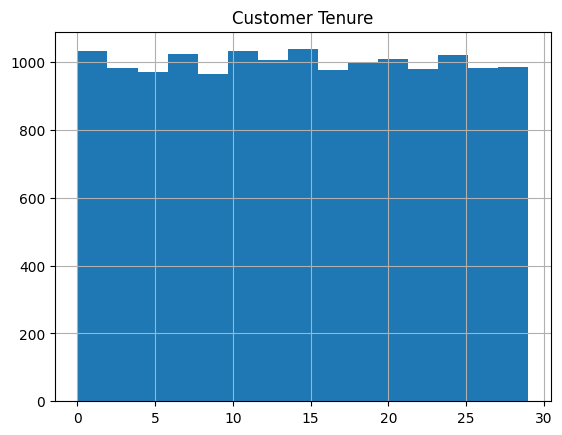

In [18]:
customers['CustomerTenureYears'].hist(bins=15)
plt.title('Customer Tenure')
plt.show()

#Customer segmentation

In [19]:
customers['SalarySegment']=pd.cut(customers['AnnualSalary'],bins=[0,500000,1000000,2000000,5000000],

labels=['Low Income','Middle Income','Upper Middle','High Income']
)

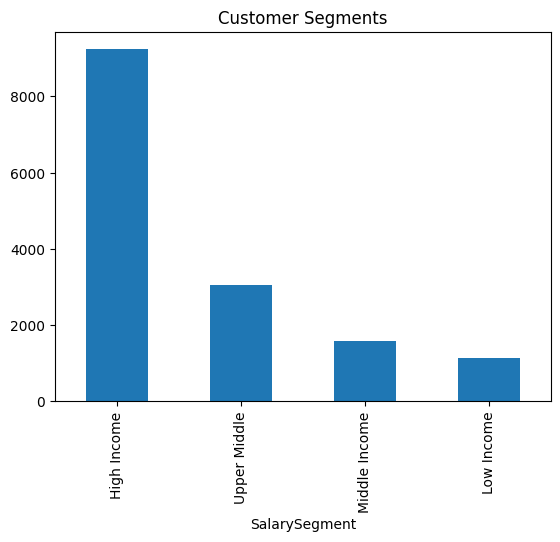

In [20]:
customers['SalarySegment'].value_counts().plot(kind='bar')

plt.title('Customer Segments')

plt.show()

# High value customers

In [21]:
premium=customers[(customers['AnnualSalary']>2000000)
&
(customers['CreditScore']>750)
]

In [22]:
len(premium)

2854

In [23]:
customers.to_csv('customers_analytics.csv',index=False)